# library 

In [1]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
import statsmodels.api as sm
import numpy as np
import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.patches as mpatches
from collections import Counter
from sklearn.utils import resample

# data 불러오기

In [2]:
df = pd.read_csv('online_retail_II.csv')
print(df.head())

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


# 데이터 정리

In [3]:
# 다음 데이터를 삭제합니다.

# Customer ID가 없는 행: 익명 구매 또는 기술적인 기록일 수 있습니다. ID가 없으면 고객 행동을 추적할 수 없으므로 삭제합니다.
df = df.dropna(subset=['Customer ID'])

# 수량이 음수인 행: 제품 반품입니다. 고객이 상품을 구매한 후 반품한 것입니다. 구매가 아니므로 삭제합니다.
df = df[df['Quantity'] > 0]

# 가격이 0 이하인 행: 기술적인 오류 또는 잘못된 기록이므로 삭제합니다.
df = df[df['Price'] > 0]

# 송장이 "C"로 시작하는 행: 취소된 거래입니다. 구매가 아니므로 삭제합니다.
df = df[~df['Invoice'].astype(str).str.startswith('C')]

In [4]:

df = df.rename(columns={
    'Customer ID': 'CustomerID',
    'Price': 'UnitPrice'
})

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Revenue'] = df['Quantity'] * df['UnitPrice']

print(df.shape)

(805549, 9)


In [5]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')
print(df.shape)
print(df.head)

(805549, 10)
<bound method NDFrame.head of         Invoice StockCode                          Description  Quantity  \
0        489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1        489434    79323P                   PINK CHERRY LIGHTS        12   
2        489434    79323W                  WHITE CHERRY LIGHTS        12   
3        489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4        489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   
...         ...       ...                                  ...       ...   
1067366  581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
1067367  581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
1067368  581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
1067369  581587     22138        BAKING SET 9 PIECE RETROSPOT          3   
1067370  581587      POST                              POSTAGE         1   

                InvoiceDate  UnitPrice  Cust

In [6]:
panel = df.groupby(['CustomerID', 'Month']).agg(
    Frequency=('Invoice', 'nunique'),
    Monthly_Revenue=('Revenue', 'sum')
).reset_index()

panel = panel.sort_values(['CustomerID', 'Month'])

print(panel.head(10))

   CustomerID    Month  Frequency  Monthly_Revenue
0     12346.0  2009-12          5           113.50
1     12346.0  2010-01          4            90.00
2     12346.0  2010-03          1            27.05
3     12346.0  2010-06          1           142.31
4     12346.0  2011-01          1         77183.60
5     12347.0  2010-10          1           611.53
6     12347.0  2010-12          1          1423.58
7     12347.0  2011-01          1           475.39
8     12347.0  2011-04          1           636.25
9     12347.0  2011-06          1           382.52


In [7]:
panel['Next_Month'] = panel.groupby('CustomerID')['Month'].shift(-1)
panel['Month_Diff'] = (panel['Next_Month'] - panel['Month']).apply(
    lambda x: x.n if pd.notna(x) else None
)
panel['Repurchase'] = (panel['Month_Diff'] <= 2).astype(int)
panel = panel.dropna(subset=['Next_Month'])

print("패널 구조:")
print(panel.shape)
print(panel.head(10))

print("재구매 분포:")
print(panel['Repurchase'].value_counts())

print("재구매 비율:")
print(round(panel['Repurchase'].mean() * 100, 2), "%")

패널 구조:
(19717, 7)
    CustomerID    Month  Frequency  Monthly_Revenue Next_Month  Month_Diff  \
0      12346.0  2009-12          5           113.50    2010-01         1.0   
1      12346.0  2010-01          4            90.00    2010-03         2.0   
2      12346.0  2010-03          1            27.05    2010-06         3.0   
3      12346.0  2010-06          1           142.31    2011-01         7.0   
5      12347.0  2010-10          1           611.53    2010-12         2.0   
6      12347.0  2010-12          1          1423.58    2011-01         1.0   
7      12347.0  2011-01          1           475.39    2011-04         3.0   
8      12347.0  2011-04          1           636.25    2011-06         2.0   
9      12347.0  2011-06          1           382.52    2011-08         2.0   
10     12347.0  2011-08          1           584.91    2011-10         2.0   

    Repurchase  
0            1  
1            1  
2            0  
3            0  
5            1  
6            1  
7   

Frequency threshold: 7.0


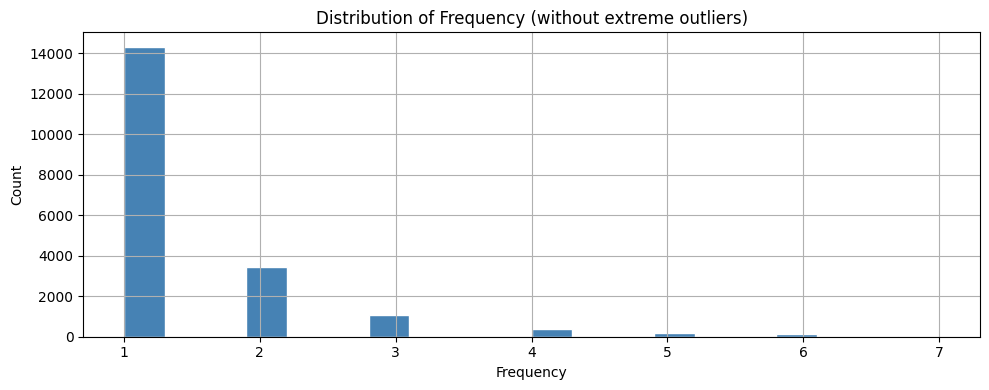

In [8]:
threshold = panel['Frequency'].quantile(0.99)

print("Frequency threshold:", round(threshold, 2))

plt.figure(figsize=(10, 4))

panel[panel['Frequency'] <= threshold]['Frequency'].hist(
    bins=20,
    color='steelblue',
    edgecolor='white'
)

plt.title('Distribution of Frequency (without extreme outliers)')
plt.xlabel('Frequency')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

Revenue threshold: 7186.15


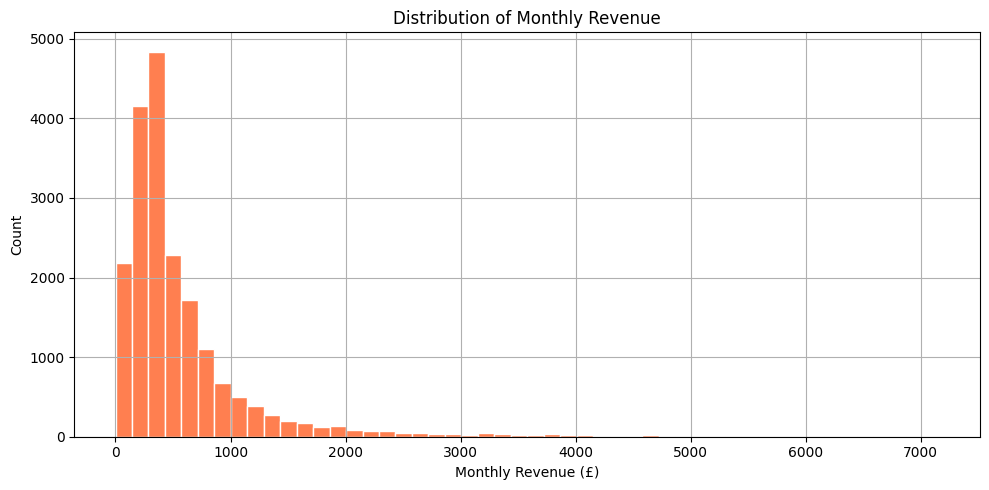

In [9]:
threshold = panel['Monthly_Revenue'].quantile(0.99)

print("Revenue threshold:", round(threshold, 2))

plt.figure(figsize=(10, 5))

panel[panel['Monthly_Revenue'] <= threshold]['Monthly_Revenue'].hist(
    bins=50,
    color='coral',
    edgecolor='white'
)

plt.title('Distribution of Monthly Revenue')
plt.xlabel('Monthly Revenue (£)')
plt.ylabel('Count')

plt.tight_layout()
plt.savefig('plot_revenue.png', dpi=150)

plt.show()

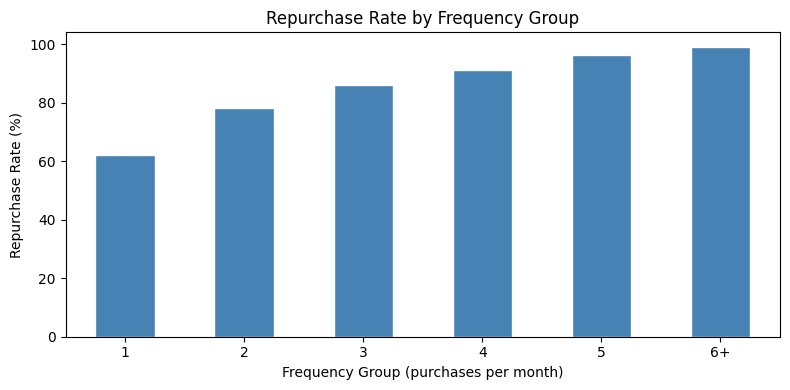

Repurchase rate by Frequency Group:
Freq_Group
1     62.23
2     78.22
3     86.01
4     91.10
5     96.49
6+    99.12
Name: Repurchase, dtype: float64


In [10]:
panel['Freq_Group'] = pd.cut(panel['Frequency'], 
                              bins=[0, 1, 2, 3, 4, 5, 100], 
                              labels=['1', '2', '3', '4', '5', '6+'])

repurchase_by_freq = panel.groupby('Freq_Group', observed=True)['Repurchase'].mean() * 100

plt.figure(figsize=(8, 4))
repurchase_by_freq.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Repurchase Rate by Frequency Group')
plt.xlabel('Frequency Group (purchases per month)')
plt.ylabel('Repurchase Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('plot_repurchase_by_freq.png', dpi=150)
plt.show()
print("Repurchase rate by Frequency Group:")
print(repurchase_by_freq.round(2))

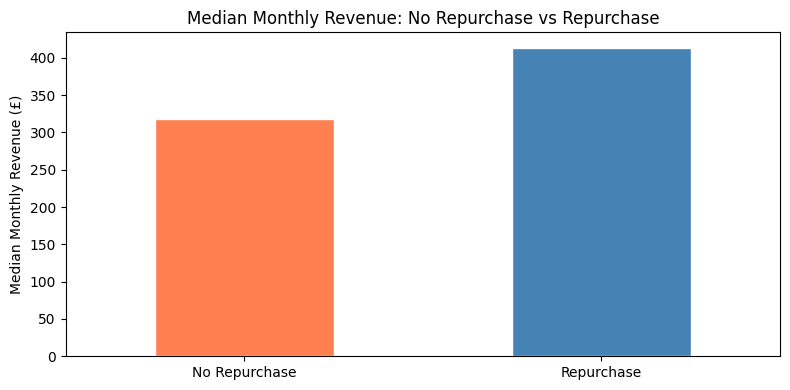


그룹별 Median Monthly Revenue:
Repurchase
0    318.38
1    413.45
Name: Monthly_Revenue, dtype: float64


In [11]:
plt.figure(figsize=(8, 4))

panel.groupby('Repurchase')['Monthly_Revenue'].median().plot(
    kind='bar',
    color=['coral', 'steelblue'],
    edgecolor='white'
)

plt.title('Median Monthly Revenue: No Repurchase vs Repurchase')
plt.xlabel('')

plt.xticks(
    [0, 1],
    ['No Repurchase', 'Repurchase'],
    rotation=0
)

plt.ylabel('Median Monthly Revenue (£)')

plt.tight_layout()
plt.savefig('plot_revenue_by_repurchase.png', dpi=150)

plt.show()

print("\n그룹별 Median Monthly Revenue:")
print(
    panel.groupby('Repurchase')['Monthly_Revenue']
    .median()
    .round(2)
)

# H1: Logistic Regression

In [12]:
# ============================================================
# H1: Frequency가 재구매에 미치는 영향
# 방법: 로지스틱 회귀 (statsmodels)
# ============================================================

X = panel[['Frequency']]
y = panel['Repurchase']

X_const = sm.add_constant(X)
logit_model = sm.Logit(y, X_const)
result_continuous = logit_model.fit()

print("=== А: 연속 Frequency ===")
print(result_continuous.summary())

coef_a = result_continuous.params['Frequency']
pval_a = result_continuous.pvalues['Frequency']
or_a = np.exp(coef_a)

print(f"\n계수: {coef_a:.4f}")
print(f"p-value:     {pval_a:.4f}")
print(f"Odds Ratio:  {or_a:.4f}")
print(f"→ Frequency가 1 증가할 때 재구매 확률은 {or_a:.2f}배 증가합니다")

# ---- B: 그룹별 비교 ----
h1_data = panel[
    (panel['Frequency'] == 1) | (panel['Frequency'] >= 3)
].copy()
h1_data['Freq_Binary'] = (h1_data['Frequency'] >= 3).astype(int)

X_h1 = sm.add_constant(h1_data[['Freq_Binary']])
y_h1 = h1_data['Repurchase']

logit_model_b = sm.Logit(y_h1, X_h1)
result_group = logit_model_b.fit()

print("\n=== B: 그룹별 비교 (Frequency=1 vs Frequency≥3) ===")
print(result_group.summary())

coef_b = result_group.params['Freq_Binary']
pval_b = result_group.pvalues['Freq_Binary']
or_b = np.exp(coef_b)
ci_b = np.exp(result_group.conf_int().loc['Freq_Binary'])

print(f"\n계수: {coef_b:.4f}")
print(f"p-value:     {pval_b:.4f}")
print(f"Odds Ratio:  {or_b:.4f}")
print(f"95% CI:      [{ci_b[0]:.4f}, {ci_b[1]:.4f}]")

if pval_b < 0.05:
    print(f"\n✓ H1 가설 채택 (p < 0.05)")
    print(f"  Frequency ≥ 3 고객은 Frequency = 1 고객보다 재구매 확률이 {or_b:.2f}배 높습니다")
else:
    print(f"\n✗ H1 가설 기각 (p = {pval_b:.4f})")

Optimization terminated successfully.
         Current function value: 0.604503
         Iterations 7
=== А: 연속 Frequency ===
                           Logit Regression Results                           
Dep. Variable:             Repurchase   No. Observations:                19717
Model:                          Logit   Df Residuals:                    19715
Method:                           MLE   Df Model:                            1
Date:                Thu, 04 Jun 2026   Pseudo R-squ.:                 0.03804
Time:                        15:10:59   Log-Likelihood:                -11919.
converged:                       True   LL-Null:                       -12390.
Covariance Type:            nonrobust   LLR p-value:                4.964e-207
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1469      0.037     -3.927      0.000      -0.220      -0.074
Frequ

# H2 — Mixed Effects Model

In [13]:
# ============================================================
# H2: 이전 달 구매 빈도(Frequency)가 당월 매출에 미치는 영향
# 방법: Mixed Effects Model (랜덤 효과 = CustomerID)
# ============================================================

# --- 1단계: 데이터 정렬 및 lag 변수 생성 ---
panel_sorted = panel.sort_values(['CustomerID', 'Month'])

# 이전 달 Frequency (lag 1)
panel_sorted['Frequency_lag1'] = panel_sorted.groupby('CustomerID')['Frequency'].shift(1)

# 이전 달 Revenue (통제 변수)
panel_sorted['Revenue_lag1'] = panel_sorted.groupby('CustomerID')['Monthly_Revenue'].shift(1)

# lag가 없는 행 제거 (각 고객의 첫 번째 달)
panel_lag = panel_sorted.dropna(subset=['Frequency_lag1', 'Revenue_lag1'])

print(f"lag 추가 후 관측치 수: {panel_lag.shape[0]}")

# --- 2단계: Revenue 로그 변환 ---
panel_lag = panel_lag.copy()
panel_lag['Log_Revenue'] = np.log1p(panel_lag['Monthly_Revenue'])
panel_lag['Log_Revenue_lag1'] = np.log1p(panel_lag['Revenue_lag1'])

print("\n로그 변환 후 분포 확인:")
print(panel_lag[['Monthly_Revenue', 'Log_Revenue']].describe().round(2))

# --- 3단계: Mixed Effects Model 실행 ---
model = smf.mixedlm(
    "Log_Revenue ~ Frequency_lag1 + Log_Revenue_lag1",
    data=panel_lag,
    groups=panel_lag['CustomerID']
)
result = model.fit()

print("\n")
print(result.summary())

# --- 4단계: 결과 해석 ---
coef = result.params['Frequency_lag1']
pval = result.pvalues['Frequency_lag1']
percent_effect = (np.exp(coef) - 1) * 100

print("\n--- H2 결과 해석 ---")
print(f"계수 (Frequency_lag1):     {coef:.4f}")
print(f"p-value:                   {pval:.4f}")
print(f"매출 변화율:               {percent_effect:.2f}%")

if pval < 0.05:
    print(f"\n✓ H2 가설 채택 (p < 0.05)")
    print(f"  이전 달 Frequency가 1 증가할 때")
    print(f"  당월 매출은 평균 {percent_effect:.1f}% 증가합니다")
else:
    print(f"\n✗ H2 가설 기각 (p = {pval:.4f})")
    print(f"  Frequency_lag1은 Monthly Revenue에 유의미한 영향을 미치지 않습니다")

lag 추가 후 관측치 수: 15617

로그 변환 후 분포 확인:
       Monthly_Revenue  Log_Revenue
count         15617.00     15617.00
mean            800.76         6.05
std            2193.40         0.97
min               0.85         0.62
25%             244.65         5.50
50%             390.60         5.97
75%             704.92         6.56
max           75412.64        11.23


          Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: Log_Revenue
No. Observations:  15617   Method:             REML       
No. Groups:        3030    Scale:              0.4190     
Min. group size:   1       Log-Likelihood:     -17369.7076
Max. group size:   23      Converged:          Yes        
Mean group size:   5.2                                    
----------------------------------------------------------
                 Coef. Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept        4.917    0.062 79.240 0.000  4.796  5.03

# Logistic Regression vs MLP

In [14]:
# ============================================================
# Recency 계산 및 panel2 생성
# ============================================================
df['Month'] = df['InvoiceDate'].dt.to_period('M')

recency_panel = df.groupby(['CustomerID', 'Month']).agg(
    Last_Purchase=('InvoiceDate', 'max')
).reset_index()

recency_panel['Month_End'] = recency_panel['Month'].dt.to_timestamp('M')
recency_panel['Recency'] = (
    recency_panel['Month_End'] - recency_panel['Last_Purchase']
).dt.days
recency_panel['Recency'] = recency_panel['Recency'].clip(lower=0)

print("Recency 기초 통계:")
print(recency_panel['Recency'].describe().round(2))

panel2 = panel.merge(
    recency_panel[['CustomerID', 'Month', 'Recency']],
    on=['CustomerID', 'Month'],
    how='left'
)

print(f"\n데이터 크기: {panel2.shape}")
print(f"결측치:\n{panel2.isnull().sum()}")

Recency 기초 통계:
count    25595.00
mean        12.83
std          8.66
min          0.00
25%          5.00
50%         12.00
75%         20.00
max         29.00
Name: Recency, dtype: float64

데이터 크기: (19717, 9)
결측치:
CustomerID         0
Month              0
Frequency          0
Monthly_Revenue    0
Next_Month         0
Month_Diff         0
Repurchase         0
Freq_Group         0
Recency            0
dtype: int64


In [15]:
# ============================================================
# ML 모델 비교: Logistic Regression vs MLP
# 특징: Frequency + Monthly_Revenue (2개 변수)
# ============================================================
from collections import Counter
from sklearn.utils import resample

X = panel2[['Frequency', 'Monthly_Revenue']]
y = panel2['Repurchase']

print(f"전체 데이터 크기: {X.shape}")
print(f"재구매 비율: {round(y.mean() * 100, 2)}%")
print(f"클래스 분포: 0 = {(y==0).sum()}, 1 = {(y==1).sum()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n학습 데이터: {X_train.shape[0]}행")
print(f"테스트 데이터: {X_test.shape[0]}행")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_df = pd.DataFrame(X_train_scaled)
y_train_series = pd.Series(y_train.values)
X_0 = X_train_df[y_train_series == 0]
X_1 = X_train_df[y_train_series == 1]
X_1_downsampled = resample(X_1, n_samples=len(X_0), random_state=42)
X_train_balanced = pd.concat([X_0, X_1_downsampled]).values
y_train_balanced = np.array([0] * len(X_0) + [1] * len(X_0))

print(f"\n균형 조정 후 클래스 분포: {Counter(y_train_balanced)}")

lr = LogisticRegression(random_state=42)
lr.fit(X_train_balanced, y_train_balanced)
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1])

print("\n=== Logistic Regression ===")
print(classification_report(y_test, lr.predict(X_test_scaled), zero_division=0))
print(f"AUC: {lr_auc:.4f}")

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=200,
    random_state=42
)
mlp.fit(X_train_balanced, y_train_balanced)
mlp_auc = roc_auc_score(y_test, mlp.predict_proba(X_test_scaled)[:, 1])

print("\n=== MLP (신경망) ===")
print(classification_report(y_test, mlp.predict(X_test_scaled), zero_division=0))
print(f"AUC: {mlp_auc:.4f}")

lr_2feat_auc = lr_auc
mlp_2feat_auc = mlp_auc

전체 데이터 크기: (19717, 2)
재구매 비율: 67.79%
클래스 분포: 0 = 6350, 1 = 13367

학습 데이터: 15773행
테스트 데이터: 3944행

균형 조정 후 클래스 분포: Counter({np.int64(0): 5080, np.int64(1): 5080})

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.38      0.83      0.52      1270
           1       0.81      0.34      0.48      2674

    accuracy                           0.50      3944
   macro avg       0.59      0.59      0.50      3944
weighted avg       0.67      0.50      0.49      3944

AUC: 0.6179

=== MLP (신경망) ===
              precision    recall  f1-score   support

           0       0.38      0.85      0.52      1270
           1       0.82      0.33      0.47      2674

    accuracy                           0.50      3944
   macro avg       0.60      0.59      0.49      3944
weighted avg       0.68      0.50      0.49      3944

AUC: 0.6137


In [16]:
# ============================================================
# ML 모델 비교: 3개 변수 (+ Recency)
# ============================================================
X2 = panel2[['Frequency', 'Monthly_Revenue', 'Recency']].dropna()
y2 = panel2.loc[X2.index, 'Repurchase']

print(f"전체 데이터 크기: {X2.shape}")
print(f"재구매 비율: {round(y2.mean() * 100, 2)}%")
print(f"클래스 분포: 0 = {(y2==0).sum()}, 1 = {(y2==1).sum()}")

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

X2_train_df = pd.DataFrame(X2_train_scaled)
y2_train_series = pd.Series(y2_train.values)
X2_0 = X2_train_df[y2_train_series == 0]
X2_1 = X2_train_df[y2_train_series == 1]
X2_1_downsampled = resample(X2_1, n_samples=len(X2_0), random_state=42)
X2_train_balanced = pd.concat([X2_0, X2_1_downsampled]).values
y2_train_balanced = np.array([0] * len(X2_0) + [1] * len(X2_0))

print(f"\n균형 조정 후 클래스 분포: {Counter(y2_train_balanced)}")

lr2 = LogisticRegression(random_state=42)
lr2.fit(X2_train_balanced, y2_train_balanced)
lr2_auc = roc_auc_score(y2_test, lr2.predict_proba(X2_test_scaled)[:, 1])

print("\n=== Logistic Regression (3개 변수) ===")
print(classification_report(y2_test, lr2.predict(X2_test_scaled), zero_division=0))
print(f"AUC: {lr2_auc:.4f}")

mlp2 = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=200,
    random_state=42
)
mlp2.fit(X2_train_balanced, y2_train_balanced)
mlp2_auc = roc_auc_score(y2_test, mlp2.predict_proba(X2_test_scaled)[:, 1])

print("\n=== MLP (3개 변수) ===")
print(classification_report(y2_test, mlp2.predict(X2_test_scaled), zero_division=0))
print(f"AUC: {mlp2_auc:.4f}")

print("\n--- 최종 모델 비교 ---")
print(f"{'모델':<35} {'AUC':>6}")
print("-" * 43)
print(f"{'로지스틱 회귀 (Frequency + Revenue)':<35} {lr_2feat_auc:>6.4f}")
print(f"{'MLP (Frequency + Revenue)':<35} {mlp_2feat_auc:>6.4f}")
print(f"{'로지스틱 회귀 (+ Recency)':<35} {lr2_auc:>6.4f}")
print(f"{'MLP (+ Recency)':<35} {mlp2_auc:>6.4f}")
print("-" * 43)

best_auc = max(lr_2feat_auc, mlp_2feat_auc, lr2_auc, mlp2_auc)
print(f"\n최고 AUC: {best_auc:.4f}")

if lr2_auc > lr_2feat_auc or mlp2_auc > mlp_2feat_auc:
    print("→ Recency 추가 후 모델 성능이 향상되었습니다 ✓")
else:
    print("→ Recency 추가 후 성능 변화가 없습니다")

전체 데이터 크기: (19717, 3)
재구매 비율: 67.79%
클래스 분포: 0 = 6350, 1 = 13367

균형 조정 후 클래스 분포: Counter({np.int64(0): 5080, np.int64(1): 5080})

=== Logistic Regression (3개 변수) ===
              precision    recall  f1-score   support

           0       0.38      0.83      0.52      1270
           1       0.81      0.34      0.48      2674

    accuracy                           0.50      3944
   macro avg       0.59      0.59      0.50      3944
weighted avg       0.67      0.50      0.49      3944

AUC: 0.5966

=== MLP (3개 변수) ===
              precision    recall  f1-score   support

           0       0.38      0.79      0.51      1270
           1       0.80      0.40      0.53      2674

    accuracy                           0.52      3944
   macro avg       0.59      0.59      0.52      3944
weighted avg       0.66      0.52      0.52      3944

AUC: 0.6179

--- 최종 모델 비교 ---
모델                                     AUC
-------------------------------------------
로지스틱 회귀 (Frequency + Revenue)

# 최종 시각화 (4개 그래프)

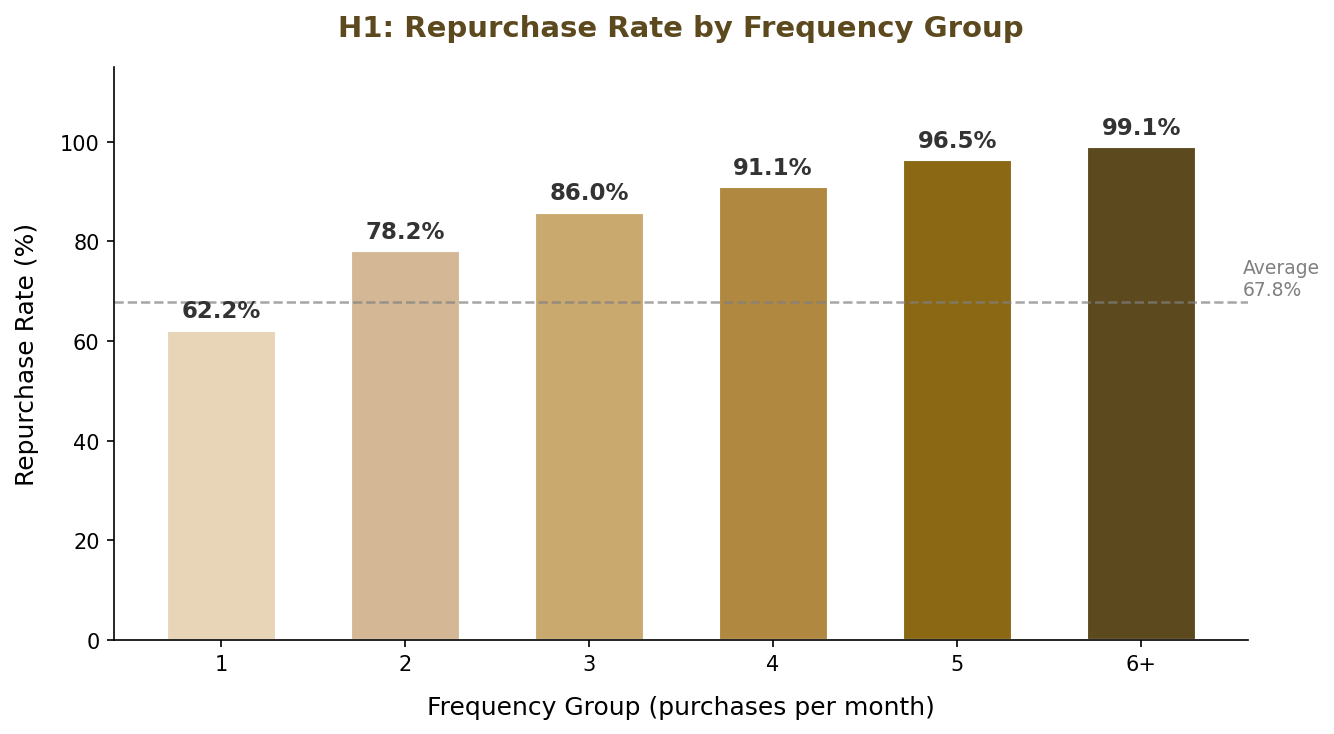

그래프 1 저장완료


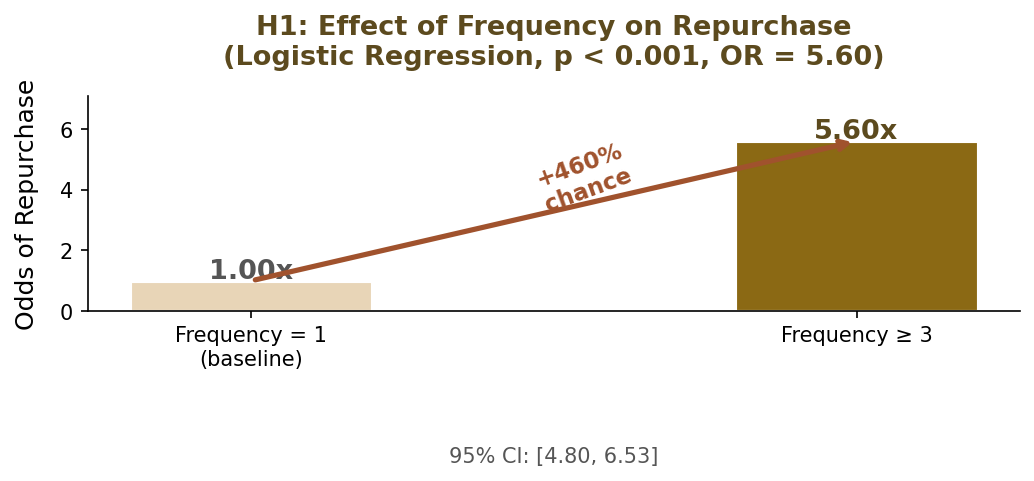

그래프 2 저장완료


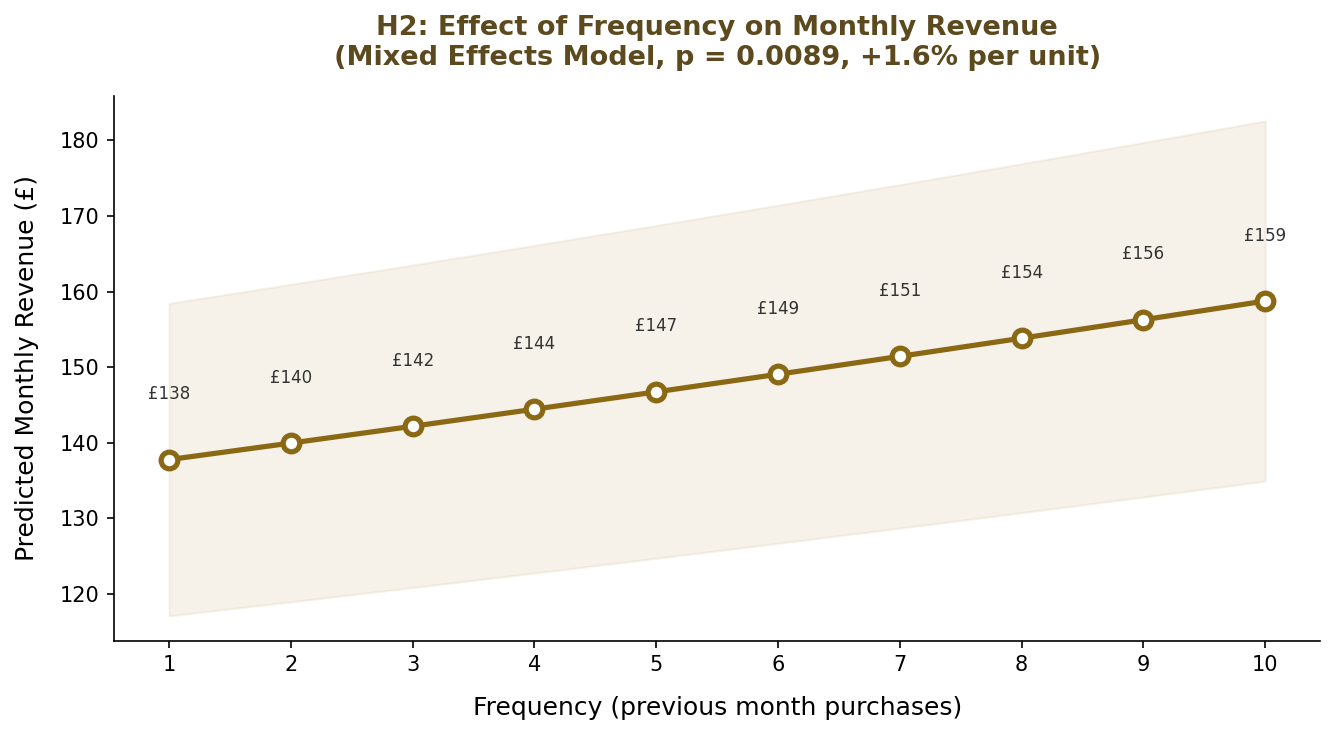

그래프 3 저장완료


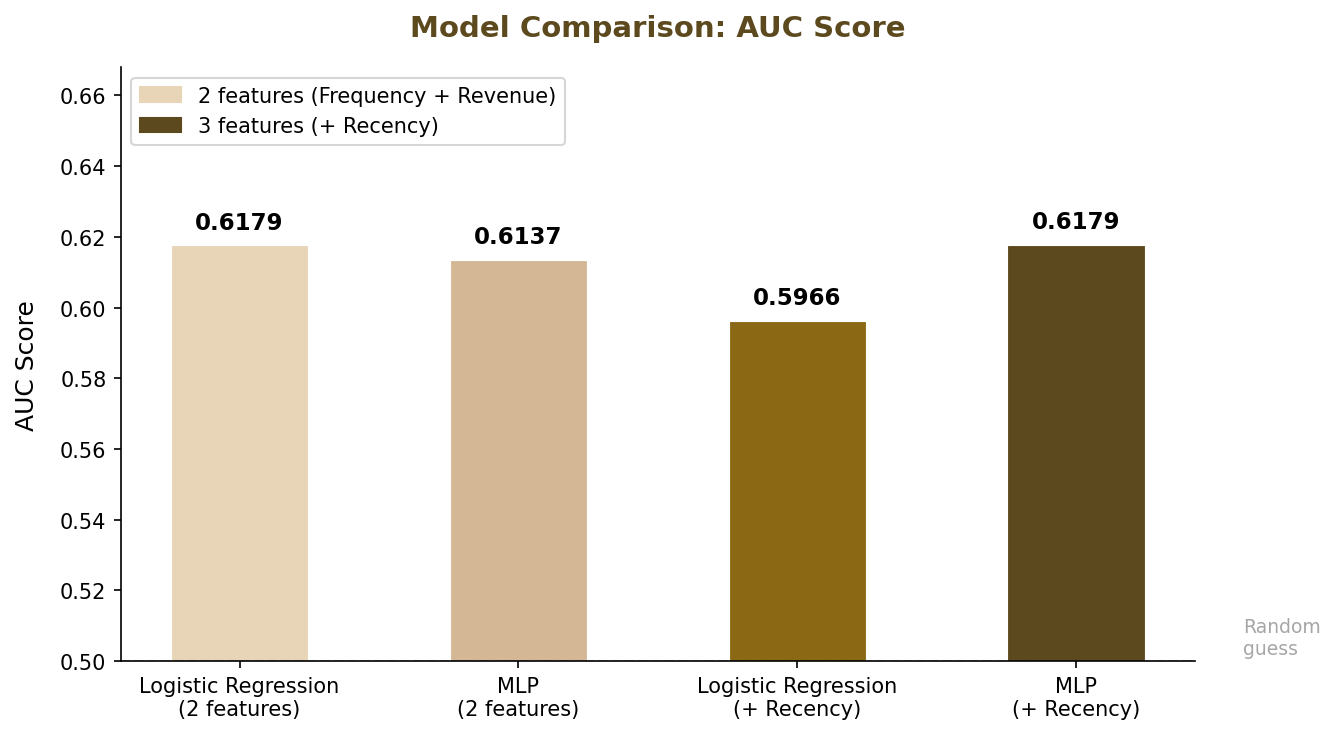

그래프 4 저장완료


In [17]:
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 150

# Цветовая палитра под презентацию
COLOR_LIGHT = '#e8d5b7'   # светло-бежевый
COLOR_MID   = '#c9a96e'   # средний бежевый
COLOR_DARK  = '#8b6914'   # тёмно-коричневый
COLOR_ACCENT = '#5c4a1e'  # очень тёмный коричневый
COLOR_ARROW = '#a0522d'   # коричнево-рыжий для стрелки

# --- 그래프 1: H1 — Repurchase Rate by Frequency Group ---
fig, ax = plt.subplots(figsize=(9, 5))

groups = repurchase_by_freq.index.tolist()
rates = repurchase_by_freq.values.tolist()

colors = ['#e8d5b7', '#d4b896', '#c9a96e', '#b08840', '#8b6914', '#5c4a1e'][:len(groups)]

bars = ax.bar(groups, rates, color=colors, edgecolor='white', linewidth=1.5, width=0.6)

for bar, rate in zip(bars, rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f'{rate:.1f}%',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold', color='#333333'
    )

avg = panel['Repurchase'].mean() * 100
ax.axhline(y=avg, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)
ax.text(len(groups) - 0.45, avg + 1.5, f'Average\n{avg:.1f}%', fontsize=9, color='gray')

ax.set_xlabel('Frequency Group (purchases per month)', fontsize=12, labelpad=10)
ax.set_ylabel('Repurchase Rate (%)', fontsize=12, labelpad=10)
ax.set_title('H1: Repurchase Rate by Frequency Group', fontsize=14, fontweight='bold', pad=15, color='#5c4a1e')
ax.set_ylim(0, 115)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('graph1_repurchase_by_freq.png', dpi=150, bbox_inches='tight')
plt.show()
print("그래프 1 저장완료")

# --- 그래프 2: H1 — Odds Ratio ---
fig, ax = plt.subplots(figsize=(7, 5))

categories = ['Frequency = 1\n(baseline)', 'Frequency ≥ 3']
values = [1.0, or_b]
colors2 = ['#e8d5b7', '#8b6914']

bars2 = ax.bar(categories, values, color=colors2,
               edgecolor='white', linewidth=1.5, width=0.4)

ax.text(0, 1.08, '1.00x', ha='center', fontsize=13,
        fontweight='bold', color='#555555')
ax.text(1, or_b + 0.08, f'{or_b:.2f}x', ha='center', fontsize=13,
        fontweight='bold', color='#5c4a1e')

ax.annotate('', xy=(1, or_b), xytext=(0, 1.0),
            arrowprops=dict(arrowstyle='->', color=COLOR_ARROW, lw=2.5))

mid_y = (1.0 + or_b) / 2
ax.text(0.55, mid_y, f'+{((or_b-1)*100):.0f}%\nchance',
        ha='center', fontsize=11, color=COLOR_ARROW,
        fontweight='bold', rotation=20)

ax.set_ylabel('Odds of Repurchase', fontsize=12, labelpad=10)
ax.set_title(f'H1: Effect of Frequency on Repurchase\n(Logistic Regression, p < 0.001, OR = {or_b:.2f})',
             fontsize=13, fontweight='bold', pad=15, color='#5c4a1e')
ax.set_ylim(0, or_b + 1.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.text(0.5, -0.7,
        f'95% CI: [{ci_b[0]:.2f}, {ci_b[1]:.2f}]',
        ha='center', fontsize=10, color='#555555',
        transform=ax.get_xaxis_transform())

plt.tight_layout()
plt.savefig('graph2_odds_ratio.png', dpi=150, bbox_inches='tight')
plt.show()
print("그래프 2 저장완료")

# --- 그래프 3: H2 — Mixed Effects ---
fig, ax = plt.subplots(figsize=(9, 5))

freq_values = np.arange(1, 11)
log_revenue_predicted = result.params['Intercept'] + coef * freq_values
revenue_predicted = np.expm1(log_revenue_predicted)

ax.plot(freq_values, revenue_predicted,
        color='#8b6914', linewidth=2.5,
        marker='o', markersize=8,
        markerfacecolor='white', markeredgewidth=2.5)

ax.fill_between(freq_values,
                revenue_predicted * 0.85,
                revenue_predicted * 1.15,
                alpha=0.15, color='#c9a96e')

for x, y in zip(freq_values, revenue_predicted):
    ax.text(x, y + 8, f'£{y:.0f}',
            ha='center', fontsize=8, color='#333333')

ax.set_xlabel('Frequency (previous month purchases)', fontsize=12, labelpad=10)
ax.set_ylabel('Predicted Monthly Revenue (£)', fontsize=12, labelpad=10)
ax.set_title(f'H2: Effect of Frequency on Monthly Revenue\n(Mixed Effects Model, p = {pval:.4f}, +{percent_effect:.1f}% per unit)',
             fontsize=13, fontweight='bold', pad=15, color='#5c4a1e')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('graph3_mixed_effects.png', dpi=150, bbox_inches='tight')
plt.show()
print("그래프 3 저장완료")

# --- 그래프 4: ML 모델 비교 ---
fig, ax = plt.subplots(figsize=(9, 5))

models = [
    'Logistic Regression\n(2 features)',
    'MLP\n(2 features)',
    'Logistic Regression\n(+ Recency)',
    'MLP\n(+ Recency)'
]
aucs = [lr_2feat_auc, mlp_2feat_auc, lr2_auc, mlp2_auc]
colors3 = ['#e8d5b7', '#d4b896', '#8b6914', '#5c4a1e']

bars3 = ax.bar(models, aucs, color=colors3,
               edgecolor='white', linewidth=1.5, width=0.5)

for bar, auc in zip(bars3, aucs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f'{auc:.4f}',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1.2, alpha=0.6)
ax.text(3.6, 0.502, 'Random\nguess', fontsize=9, color='gray', alpha=0.7)

ax.set_ylabel('AUC Score', fontsize=12, labelpad=10)
ax.set_title('Model Comparison: AUC Score', fontsize=14, fontweight='bold', pad=15, color='#5c4a1e')
ax.set_ylim(0.5, max(aucs) + 0.05)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

light_patch = mpatches.Patch(color='#e8d5b7', label='2 features (Frequency + Revenue)')
dark_patch = mpatches.Patch(color='#5c4a1e', label='3 features (+ Recency)')
ax.legend(handles=[light_patch, dark_patch], fontsize=10, loc='upper left')

plt.tight_layout()
plt.savefig('graph4_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("그래프 4 저장완료")